<a href="https://colab.research.google.com/github/marioguerrerosalah/ANALITICA-DE-NEGOCIOS/blob/main/Reto_2_analitica_de_datos_25_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto 2

Bob ha creado su propia empresa de celulares. Quiere plantar cara a grandes empresas como Apple, Samsung, etc.

No sabe cómo calcular el precio de los móviles que crea su empresa. En un mercado tan competitivo como el de la telefonía móvil, no se pueden hacer suposiciones. Para resolver este problema, recopila datos de ventas de teléfonos móviles de varias empresas.

Bob quiere averiguar la relación entre las características de un teléfono móvil (por ejemplo, RAM, memoria interna, etc.) y su precio de venta. Pero no es muy bueno en *Machine Learning*. Así que necesita tu ayuda para resolver este problema.

En este problema no tienes que predecir el precio real, sino un rango de precios que indique cómo de alto es el precio. El rango es el siguiente:

- 0 - low cost
- 1 - medium cost
- 2 - high cost
- 3 - very high cost

La base de datos contiene en total 21 características o variables predictoras. Adicionalmente, la última columna corresponde a la variable objetivo.
Toda la información de la base de datos está en el siguiente link
https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification?resource=download


Se necesitan hacer una exploracion previa de los datos. Para eso necesita

1- identificar la dimension de la base de datos
2- identificar el tipo de datos de cada una de las variables
3- Dar una informción general de la base de datos
4- Identifique y elime los datos que tenga vacios y los duplicados
5- Para todas las variables numéricas, calcule la media, la desviación estandar el maximo y el mínimo
6-Haga uan grafica de dispersion en donde en el eje X esté el la variable battery_power y en el eje y la variable ram. Adicionalmente distinga por colores cada una de las categorías de la variable price_rage

el cliente necesita implementar modelos de machine learning para predecir en que categoría de precio debería estar un celular. para esto usted debe

7- Implementar un modelo de regresión logística y un modelo de clasificacion de naive bayes tipo Gaussian.  
8- Para predecir la categoría del precio del celular use todas las demas variables
9- Para dividir los datos tenga en cuenta en usar el 75% de los datos para el entrenamiento, un aleatorio tipo 42 y sin estratificacion
10- Debe calcular las metricas para cada uno de los modelos y comentar cada uno de los resultados
11- hacer una comparación de cual modelo sería mejor usar para predecir la categoría de precio de futuros celulares.

NO SE LE OLVIDE QUE DEBE COMENTAR SUS RESULTADOS PARA QUE LA RESPUESTA SEA VALIDA


IMPORTAR LAS LIBRERIAS


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

IMPORTAR BASE DE DATOS


In [ ]:
ruta="/content/Base de datos celulares.xlsx"
base=pd.read_excel(ruta)

1. dimension de la base de datos


In [ ]:
base.shape ## la dimension de la base de datos es de (2000, 21)

(2000, 21)

2. Identificar el tipo de datos de cada variable

In [ ]:
base.dtypes ## en la base de datos hay 14 variables float64 y 7 variables de int64

,0
battery_power,float64
blue,int64
clock_speed,float64
dual_sim,int64
fc,float64
four_g,int64
int_memory,float64
m_dep,float64
mobile_wt,int64
n_cores,float64


3. Información general de la base de datos

In [ ]:
base.info

<bound method DataFrame.info of       battery_power  blue  clock_speed  dual_sim    fc  four_g  int_memory  \
0             842.0     0          2.2         0   1.0       0         7.0   
1            1021.0     1          0.5         1   0.0       1        53.0   
2             563.0     1          0.5         1   2.0       1        41.0   
3             615.0     1          2.5         0   0.0       0        10.0   
4            1821.0     1          1.2         0  13.0       1        44.0   
...             ...   ...          ...       ...   ...     ...         ...   
1995          794.0     1          0.5         1   0.0       1         2.0   
1996         1965.0     1          2.6         1   0.0       0        39.0   
1997         1911.0     0          0.9         1   1.0       1        36.0   
1998         1512.0     0          0.9         0   4.0       1        46.0   
1999          510.0     1          2.0         1   5.0       1        45.0   

      m_dep  mobile_wt  n_cores  ...  px_height  px_width     ram  sc_h  sc_w  \
0       0.6        188      2.0  ...       20.0     756.0  2549.0   9.0     7   
1       0.7        136      3.0  ...      905.0    1988.0  2631.0  17.0     3   
2       0.9        145      5.0  ...     1263.0    1716.0  2603.0  11.0     2   
3       0.8        131      6.0  ...     1216.0    1786.0  2769.0  16.0     8   
4       0.6        141      2.0  ...     1208.0    1212.0  1411.0   8.0     2   
...     ...        ...      ...  ...        ...       ...     ...   ...   ...   
1995    0.8        106      6.0  ...     1222.0    1890.0   668.0  13.0     4   
1996    0.2        187      4.0  ...      915.0    1965.0  2032.0  11.0    10   
1997    0.7        108      8.0  ...      868.0    1632.0  3057.0   9.0     1   
1998    0.1        145      5.0  ...      336.0     670.0   869.0  18.0    10   
1999    0.9        168      6.0  ...      483.0     754.0  3919.0  19.0     4   

      talk_time  three_g  touch_screen  wifi  price_range  
0          19.0        0           0.0     1          1.0  
1           7.0        1           1.0     0          2.0  
2           9.0        1           1.0     0          2.0  
3          11.0        1           0.0     0          2.0  
4          15.0        1           1.0     0          1.0  
...         ...      ...           ...   ...          ...  
1995       19.0        1           1.0     0          0.0  
1996       16.0        1           1.0     1          2.0  
1997        5.0        1           1.0     0          3.0  
1998       19.0        1           1.0     1          0.0  
1999        2.0        1           1.0     1          3.0  

[2000 rows x 21 columns]>

4. Eliminar datos vacíos y duplicados

In [ ]:
base.isnull().sum() #Hay un total de 27 vacios en la base de datos
base.duplicated().sum() ## no hay datos duplicados en la base de datos
base2=base.dropna()

base2.isnull().sum() #La base 2 ya no tiene vacios y es la que usaremos para seguir con el taller

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


5. Estadísticas de las variables numéricas

In [ ]:
##en cada una de las variables numericas le encontramos la media, el maximo, el minimo y la desviación estandar

##battery_power
base2["battery_power"].mean()
base2["battery_power"].std()
base2["battery_power"].min()
base2["battery_power"].max()
##blue
base2["blue"].mean()
base2["blue"].std()
base2["blue"].min()
base2["blue"].max()
##clock_speed
base2["clock_speed"].mean()
base2["clock_speed"].std()
base2["clock_speed"].min()
base2["clock_speed"].max()
##dual_sim
base2["dual_sim"].mean()
base2["dual_sim"].std()
base2["dual_sim"].min()
base2["dual_sim"].max()
##fc
base2["fc"].mean()
base2["fc"].std()
base2["fc"].min()
base2["fc"].max()
##four_g
base2["four_g"].mean()
base2["four_g"].std()
base2["four_g"].min()
base2["four_g"].max()
##int_memory
base2["int_memory"].mean()
base2["int_memory"].std()
base2["int_memory"].min()
base2["int_memory"].max()
##m_dep
base2["m_dep"].mean()
base2["m_dep"].std()
base2["m_dep"].min()
base2["m_dep"].max()
##mobile_wt
base2["mobile_wt"].mean()
base2["mobile_wt"].std()
base2["mobile_wt"].min()
base2["mobile_wt"].max()
##n_cores
base2["n_cores"].mean()
base2["n_cores"].std()
base2["n_cores"].min()
base2["n_cores"].max()
##pc
base2["pc"].mean()
base2["pc"].std()
base2["pc"].min()
base2["pc"].max()
##px_height
base2["px_height"].mean()
base2["px_height"].std()
base2["px_height"].min()
base2["px_height"].max()
##px_width
base2["px_width"].mean()
base2["px_width"].std()
base2["px_width"].min()
base2["px_width"].max()
##ram
base2["ram"].mean()
base2["ram"].std()
base2["ram"].min()
base2["ram"].max()
##sc_h
base2["sc_h"].mean()
base2["sc_h"].std()
base2["sc_h"].min()
base2["sc_h"].max()
##sc_w
base2["sc_w"].mean()
base2["sc_w"].std()
base2["sc_w"].min()
base2["sc_w"].max()
##talk_time
base2["talk_time"].mean()
base2["talk_time"].std()
base2["talk_time"].min()
base2["talk_time"].max()
##three_g
base2["three_g"].mean()
base2["three_g"].std()
base2["three_g"].min()
base2["three_g"].max()
##touch_screen
base2["touch_screen"].mean()
base2["touch_screen"].std()
base2["touch_screen"].min()
base2["touch_screen"].max()
##wifi
base2["wifi"].mean()
base2["wifi"].std()
base2["wifi"].min()
base2["wifi"].max()
##price_range
base2["price_range"].mean()
base2["price_range"].std()
base2["price_range"].min()
base2["price_range"].max()


3.0

6. Gráfica de dispersión battery_power vs ram

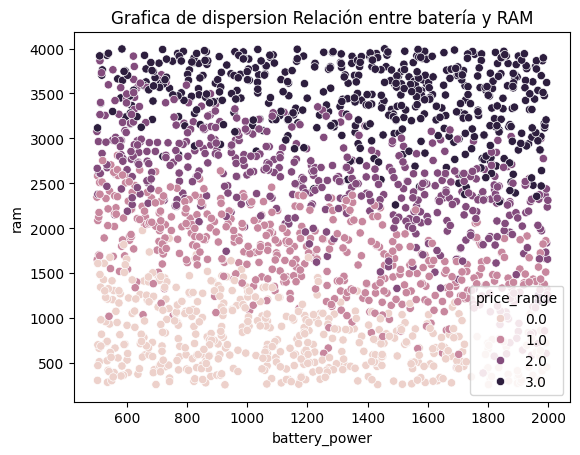

In [ ]:
sns.scatterplot(x="battery_power",y="ram",data=base2, hue="price_range")
plt.title("Grafica de dispersion Relación entre batería y RAM")
plt.xlabel("battery_power")
plt.ylabel("ram")
plt.show()

###La gráfica muestra la relación entre la batería y la RAM de los celulares, diferenciando los precios por colores. Se observa que los celulares de mayor precio (tonos oscuros) tienen más RAM, mientras que los de menor precio (tonos claros) tienen menos. Aunque la batería influye en el precio, la RAM parece ser un factor más determinante en la categorización.



7. Implementación de modelos de Machine Learning

In [ ]:
X = base2.drop(columns=['price_range'])  # Variables predictoras
y = base2['price_range']  # Variable objetivo (categoría de precio)

 9- Para dividir los datos tenga en cuenta en usar el 75% de los datos para el entrenamiento, un aleatorio tipo 42 y sin estratificacion

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


10- Debe calcular las metricas para cada uno de los modelos y comentar cada uno de los resultados

In [ ]:
##REGRESION LOGISTICA

##definir el modelo
logit=LogisticRegression()

###entrenar el modelo
logit.fit(X_train,y_train)

##Prediccion por fuera de la muestra
y_pred=logit.predict(X_test)

###MATRIZ DE CONFUSION

mc_lr =confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))

#### resumen de las metricas
print(classification_report(y_test,y_pred))

###RESPUESTA

##La matriz de confusión del modelo de Regresión Logística muestra una precisión general del 63%, con un buen desempeño en la clasificación de celulares de bajo costo (80% de precisión y 75% de recall) y muy alto costo (72% de precisión y 78% de recall). Sin embargo, el modelo tiene dificultades para diferenciar las categorías intermedias (medium cost y high cost), con precisiones cercanas al 50%, lo que indica que suele confundir estos rangos de precio.

[[101  32   2   0]
 [ 25  60  35   3]
 [  0  26  56  34]
 [  0   0  27  93]]
              precision    recall  f1-score   support

         0.0       0.80      0.75      0.77       135
         1.0       0.51      0.49      0.50       123
         2.0       0.47      0.48      0.47       116
         3.0       0.72      0.78      0.74       120

    accuracy                           0.63       494
   macro avg       0.62      0.62      0.62       494
weighted avg       0.63      0.63      0.63       494



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
##NAIVE BAYES


##definir el modelo
nb=GaussianNB() ##este es el modelo de naive bayes

###entrenar el modelo
nb.fit(X_train,y_train) # Changed x_train to X_train

##Prediccion por fuera de la muestra
y_pred=nb.predict(X_test)

##MATRIZ DE CONFUSION
mc_nb=confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))

###reporte de la clasficación
print(classification_report(y_test,y_pred))

##RESPUESTA

#La matriz de confusión del modelo Naive Bayes Gaussiano muestra un desempeño significativamente mejor que el de la regresión logística, con una precisión general del 82%. Se observa un alto rendimiento en la clasificación de todas las categorías, especialmente en la de bajo costo (93% de precisión y 88% de recall) y muy alto costo (92% de precisión y 90% de recall). Aunque el modelo aún comete algunos errores en las categorías intermedias, su rendimiento general es más equilibrado y confiable.

[[119  16   0   0]
 [  9  92  22   0]
 [  0  13  87  16]
 [  0   0  12 108]]
              precision    recall  f1-score   support

         0.0       0.93      0.88      0.90       135
         1.0       0.76      0.75      0.75       123
         2.0       0.72      0.75      0.73       116
         3.0       0.87      0.90      0.89       120

    accuracy                           0.82       494
   macro avg       0.82      0.82      0.82       494
weighted avg       0.82      0.82      0.82       494



11- hacer una comparación de cual modelo sería mejor usar para predecir la categoría de precio de futuros celulares.

In [ ]:
#Comparando ambos modelos, Naive Bayes Gaussiano es claramente la mejor opción para predecir la categoría de precio de futuros celulares. Su precisión general es 82%, mucho mayor que la de Regresión Logística (63%), lo que indica que hace mejores predicciones en todas las categorías. Además, Naive Bayes tiene un mejor equilibrio entre precisión y recall en todas las clases, mientras que la Regresión Logística tiene dificultades en las categorías intermedias y confunde más los precios. En conclusión, para clasificar celulares en rangos de precios con mayor precisión y menor margen de error, Naive Bayes Gaussiano es la opción más confiable.